Convolutional Neural Network model

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [2]:
#load the saved preprocessed data from previous notebook
X_train = np.load('../data/X_train.npy')
y_train = np.load('../data/y_train.npy')
X_test = np.load('../data/X_test.npy')
y_test = np.load('../data/y_test.npy')

print("Data loaded successfully!")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

Data loaded successfully!
X_train shape: (28709, 48, 48, 1)
y_train shape: (28709, 7)


In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

augmentation = ImageDataGenerator(
    rotation_range = 10,                # Randomly rotate images by up to 10 degrees
    width_shift_range = 0.1,            # Randomly shift images horizontally
    height_shift_range = 0.1,           # randomly shift images vertically
    horizontal_flip = True,             # Randomly flip images left-right
    zoom_range = 0.1                    # randiomly zoom in slightly
)

model = Sequential([
    #First convolutional block
    #64 filters, each 3x3 pixels, looks for basic fatures like edges
    Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(48, 48, 1)),
    BatchNormalization(),  #normalize outputs to speed up training
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)), #reducing image from 48x48 to 24x24
    Dropout(0.25), #randomly drops 25% of neurons to prevent overfitting

    #secon convolution block
    #128 filters - looks for more complex features like eyes, mouth shapes
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)), #reduces image from 24x24 to 12x12
    Dropout(0.25),

    #third convolutional block
    #256 filters - looks for high level features like overall facial expressions
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)), #reduces image from 12x12 to 6x6
    Dropout(0.25),

    #Flatten and Dense layers
    Flatten(),  #converts 6x6x256 into a single array of 9216 values
    Dense(256, activation='relu'), #fully connected layer
    BatchNormalization(),
    Dropout(0.5), #Higher dropout here to strongly prevent overfitting

    #output layer - 7 neurons for 7 emotions
    # Softmax gives probability for each emotion (all add up to 1.0)
    Dense(7, activation='softmax')
])

model.summary()

c:\Users\Vindiya\Documents\GitHub\FaceEmo\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 3,510,215 (13.39 MB)

 Trainable params: 3,507,911 (13.38 MB)

 Non-trainable params: 2,304 (9.00 KB)

In [4]:
#compile defines how the model learns
model.compile(
    #Adam optimizer - adjusts learning rate automatically
    optimizer = 'adam',

    #loss function for multi-class classification
    loss='categorical_crossentropy',

    #metric we want to track
    metrics=['accuracy']
)

print("Model compiled successfully! ")

Model compiled successfully! 


In [5]:
#callbacks

#EarlyStopping - stops training if validation accuracy stops improving
# patience=5 means it waits 5 epochs before stopping

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True           #keep the best version of the model
)

#ModelCheckpoint - saves the best model automatically during training
model_checkpoint = ModelCheckpoint(
    filepath='../models/best_model.keras',
    monitor='val_accuracy',
    save_best_only= True,   #only saves when accuracy improves
    verbose=1
)

print("Callbacks ready!")

Callbacks ready!


In [9]:
#Train the model

history = model.fit(
    augmentation.flow(X_train, y_train, batch_size=64),      #batch_size=64, num of images processed at once
    epochs=50,                                               #maximum num of training rounds
    validation_data=(X_test, y_test),                            #use 20% of training data for validation
    callbacks=[early_stopping, model_checkpoint],
    verbose = 1
)

print("Training complete!")


Epoch 1/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2310 - loss: 2.2624
Epoch 1: val_accuracy improved from None to 0.31889, saving model to ../models/best_model.keras

Epoch 1: finished saving model to ../models/best_model.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 502s 1s/step - accuracy: 0.2767 - loss: 2.0129 - val_accuracy: 0.3189 - val_loss: 1.8711
Epoch 2/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3873 - loss: 1.6026
Epoch 2: val_accuracy improved from 0.31889 to 0.49401, saving model to ../models/best_model.keras

Epoch 2: finished saving model to ../models/best_model.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 512s 1s/step - accuracy: 0.4209 - loss: 1.5185 - val_accuracy: 0.4940 - val_loss: 1.3599
Epoch 3/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4867 - loss: 1.3448
Epoch 3: val_accuracy improved from 0.49401 to 0.52104, saving model to ../models/best_model.keras

Epoch 3: finished saving model to ../models/best_model.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 

Final Training Accuracy: 0.6662
Final Validation Accuracy: 0.6457


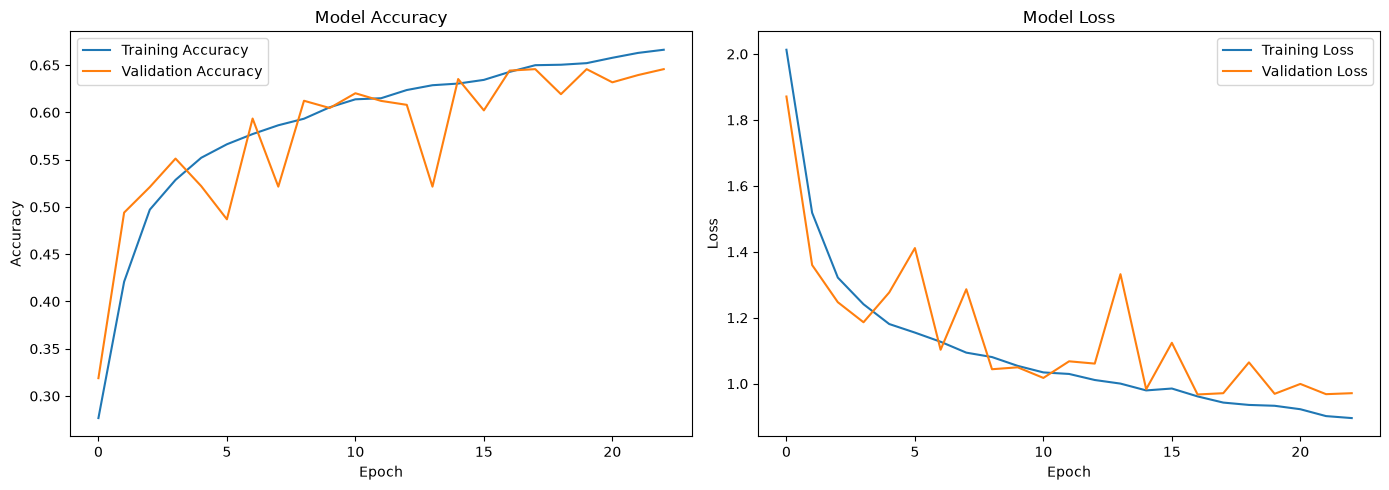

In [10]:
#plot training results

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#accuracy plot
axes[0].plot(history.history['accuracy'], label='Training Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

#Loss plot
axes[1].plot(history.history['loss'], label='Training Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('../models/training_curves.png')    #save the plot

print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")